<a href="https://colab.research.google.com/github/Bharathkumar-Tamilarasu/Algerian-Fire-Forecaster/blob/main/Algerian_Fire_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Algerian Forest Fires Analysis

##### **Project Type**    - Machine Learning
##### **Contribution**    - Individual
##### **Team Member 1 -** Bharathkumar Tamilarasu

# **GitHub Link**

https://github.com/Bharathkumar-Tamilarasu/Algerian-Fire-Forecaster

## ***1. Know Your Data***

### **Algerian Forest Fires Dataset**

### *Data Set Information:*

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012. The dataset includes 11 attribues and 1 output attribue (class) The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

### *Attribute Information:*


* Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
* Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
* RH : Relative Humidity in %: 21 to 90
* Ws :Wind speed in km/h: 6 to 29
* Rain: total day in mm: 0 to 16.8 FWI Components
* Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
* Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
* Drought Code (DC) index from the FWI system: 7 to 220.4
* Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
* Buildup Index (BUI) index from the FWI system: 1.1 to 68
* Fire Weather Index (FWI) Index: 0 to 31.1
* Classes: two classes, namely Fire and not Fire

### Import Libraries

In [95]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Dataset Loading

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
# Loading Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Self Projects/ML Projects/Algerian Fire Forecaster/Algerian_forest_fires_dataset_UPDATE.csv',header=1)

### Dataset First View

In [98]:
# Dataset First Look
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### Dataset Rows & Columns count

In [99]:
# Dataset Rows & Columns count
df.shape

(246, 14)

Obeservation: Dataset has 246 rows and 14 columns.

### Dataset Information

In [100]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


#### Duplicate Values

In [101]:
# Dataset Duplicate Value Count
print(df[df.duplicated() == True].shape)

(0, 14)


Obeservation: Dataset doesnt contain any duplicate rows

#### Missing Values/Null Values

In [102]:
# Missing Values/Null Values Count
df.isna().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

Observation: We found missing values on all columns except 'Day' column


## ***2. Understanding Your Variables***

In [103]:
# Dataset Columns
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [104]:
# Dataset Describe
df.describe(include = 'all')

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,128,9
top,01,07,2012,35,64,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


## ***3. Data Wrangling***

In [105]:
# Data Set information before wrangling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [106]:
# Identified Unnecessary Rows (i.e 122& 123)

df.loc[120:130,:]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
120,29,09,2012,26,80,16,1.8,47.4,2.9,7.7,0.3,3,0.1,not fire
121,30,09,2012,25,78,14,1.4,45,1.9,7.5,0.2,2.4,0.1,not fire
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
124,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
125,02,06,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire
126,03,06,2012,29,80,14,2,48.7,2.2,7.6,0.3,2.6,0.1,not fire
127,04,06,2012,30,64,14,0,79.4,5.2,15.4,2.2,5.6,1,not fire
128,05,06,2012,32,60,14,0.2,77.1,6,17.6,1.8,6.5,0.9,not fire
129,06,06,2012,35,54,11,0.1,83.7,8.4,26.3,3.1,9.3,3.1,fire


In [107]:
# Dropping those rows

df.drop([122,123],axis=0,inplace=True)
df.reset_index(drop=True,inplace=True)

In [108]:
# Checking if any rows have a null value

df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
165,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [109]:
# Dropping the rows

df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

In [110]:
# Removing the extra spaces in column names

df.columns = df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [111]:
# Adding a Region column

# Label 0 for Bejaia Region
# Label 1 for Sidi-Bel Abbes Region

df.loc[:121,'Region']=0
df.loc[122:,'Region']=1

The dataset is converted into two sets based on Region. Added a new column 'Region'

0 : "Bejaia Region Dataset" - From 0th - 121st Index

1 : "Sidi-Bel Abbes Region Dataset" - From 122nd - 243rd Index



In [112]:
# Changing Data Types of the columns

columns_tobechanged_int = ['day', 'month', 'year', 'Temperature', 'RH', 'Ws','Region']
df[columns_tobechanged_int]=df[columns_tobechanged_int].astype(int)

columns_tobechanged_float = [col for col in df.columns if (df[col].dtype==object and col!='Classes')]
df[columns_tobechanged_float]=df[columns_tobechanged_float].astype(float)

In [113]:
# Removing additional spaces of the categorical values of 'Classes' column

df['Classes']=df['Classes'].str.strip()

In [114]:
# Data Set information after wrangling

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [115]:
# Saving the cleaned Data Set

df.to_csv('/content/drive/MyDrive/Colab Notebooks/Self Projects/ML Projects/Algerian Fire Forecaster/Algerian_forest_fires_dataset_cleaned.csv',index=False)

## ***4. EDA***

In [116]:
# Creating a copy

df_copy = df.copy()

# Dropping columns which we will not use

df_copy.drop(['day','month','year'],axis=1,inplace=True)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [117]:
# Encoding of the categories in Classes column

df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

<ipython-input-118-6c7ea401bb90>:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


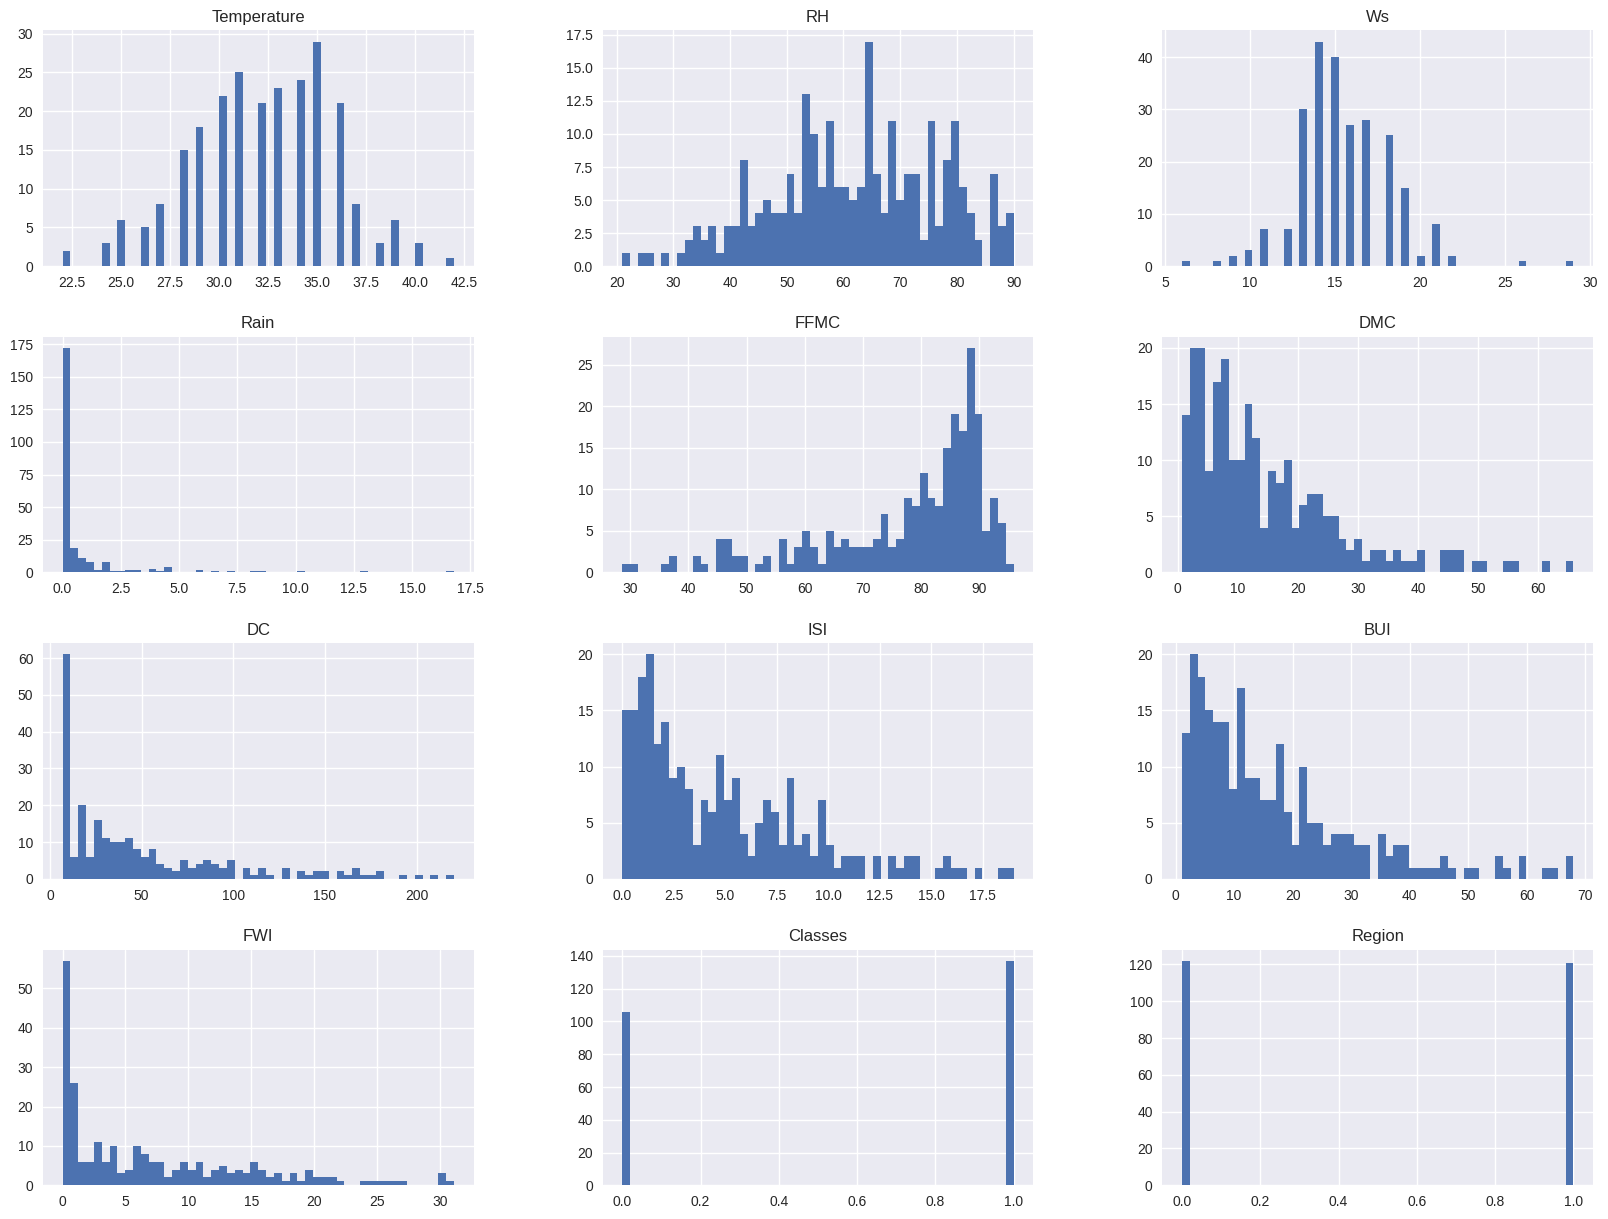

In [118]:
# Plotting desnity plot for all features

plt.style.use('seaborn')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [119]:
# Creating a Pie Chart

values = np.array(df_copy['Classes'].value_counts(normalize=True)*100)
pielabels = ['Fire','Not Fire']
piecolors = ['#FF0000','#007500']

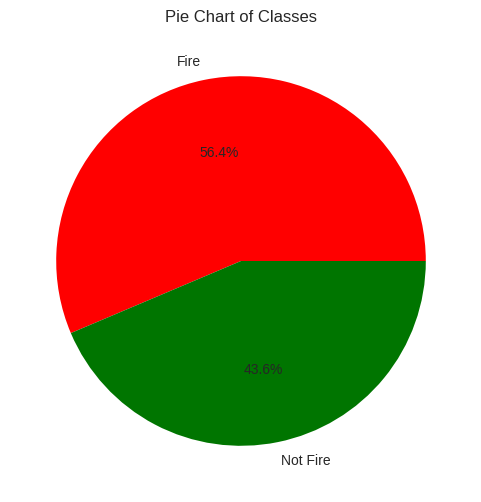

In [120]:
plt.figure(figsize=(6,6))
plt.pie(values,labels=pielabels,colors=piecolors,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

In [121]:
# Correlation

df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


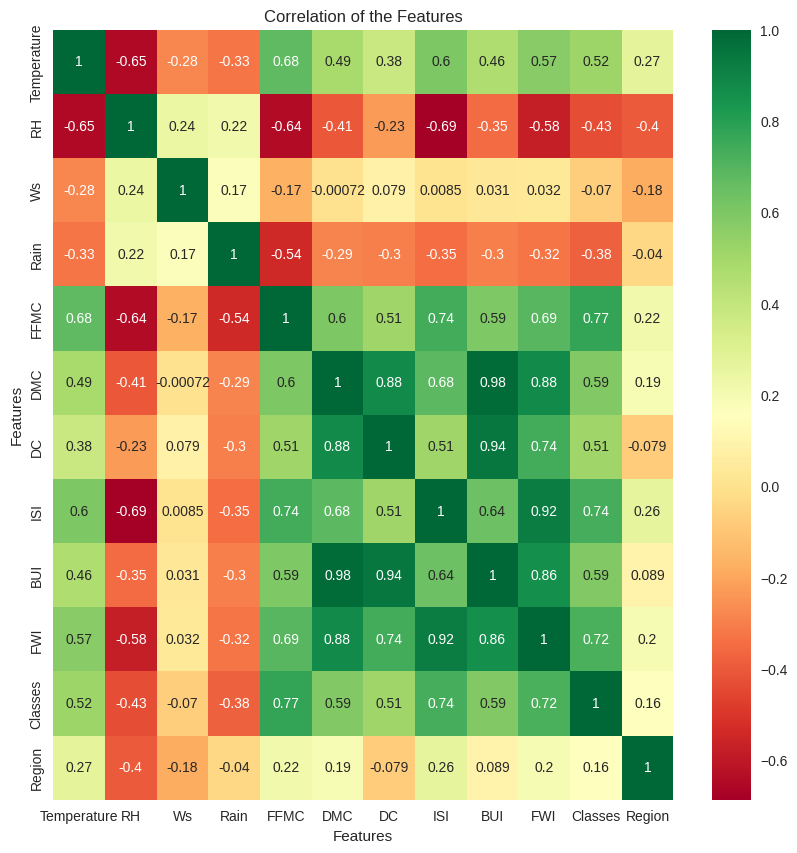

In [122]:
# Correlation using Heatmap

plt.figure(figsize=(10,10))
sns.heatmap(df_copy.corr(),cmap='RdYlGn',annot=True)
plt.title('Correlation of the Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

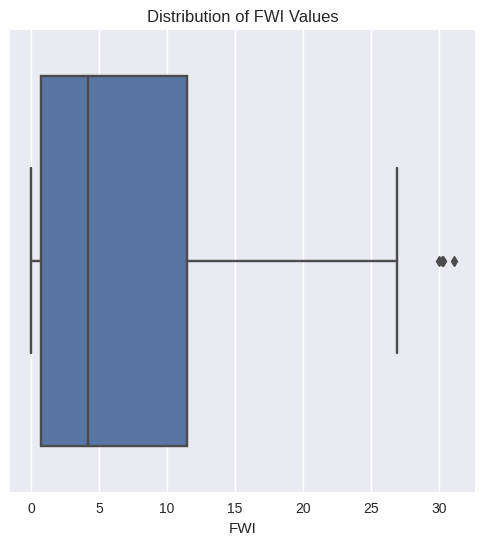

In [123]:
# Creating a Box Plot for FWI

plt.figure(figsize=(6,6))
sns.boxplot(x=df_copy['FWI'])
plt.title('Distribution of FWI Values')
plt.show()

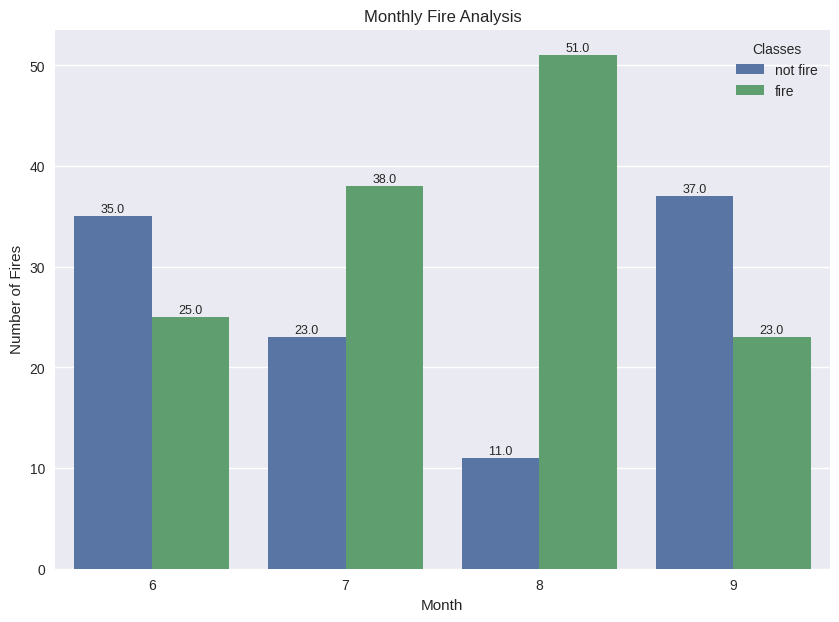

In [124]:
# Monthly Fire Analysis

plt.figure(figsize=(10,7))
bar_plot = sns.countplot(df,x='month',hue='Classes')
plt.title('Monthly Fire Analysis')
plt.xlabel('Month')
plt.ylabel('Number of Fires')
for bar in bar_plot.patches:

  # Using Matplotlib's annotate function and
  # passing the coordinates where the annotation shall be done
  # x-coordinate: bar.get_x() + bar.get_width() / 2
  # y-coordinate: bar.get_height()
  # free space to be left to make graph pleasing: (0, 8)
  # ha and va stand for the horizontal and vertical alignment
    bar_plot.annotate(format(bar.get_height()),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=9, xytext=(0, 5),
                   textcoords='offset points')
plt.show()

Its observed that July and August had the most number of forest fires for both regions. And from the above plot of months, we can understand few things

Most of the fires happened in August

Less Fires was on September

## ***5. Model Training***

In [125]:
# Independent and Dependent Variables
X=df_copy.drop(['FWI'],axis=1)
y=df_copy['FWI']

In [126]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=None)

In [127]:
print('Shapes\nX Train ->',X_train.shape)
print('X Test ->',X_test.shape)
print('Y Train ->',y_train.shape)
print('Y Test ->',y_test.shape)

Shapes
X Train -> (170, 11)
X Test -> (73, 11)
Y Train -> (170,)
Y Test -> (73,)


###**i) Feature Selection Based on Correlation**

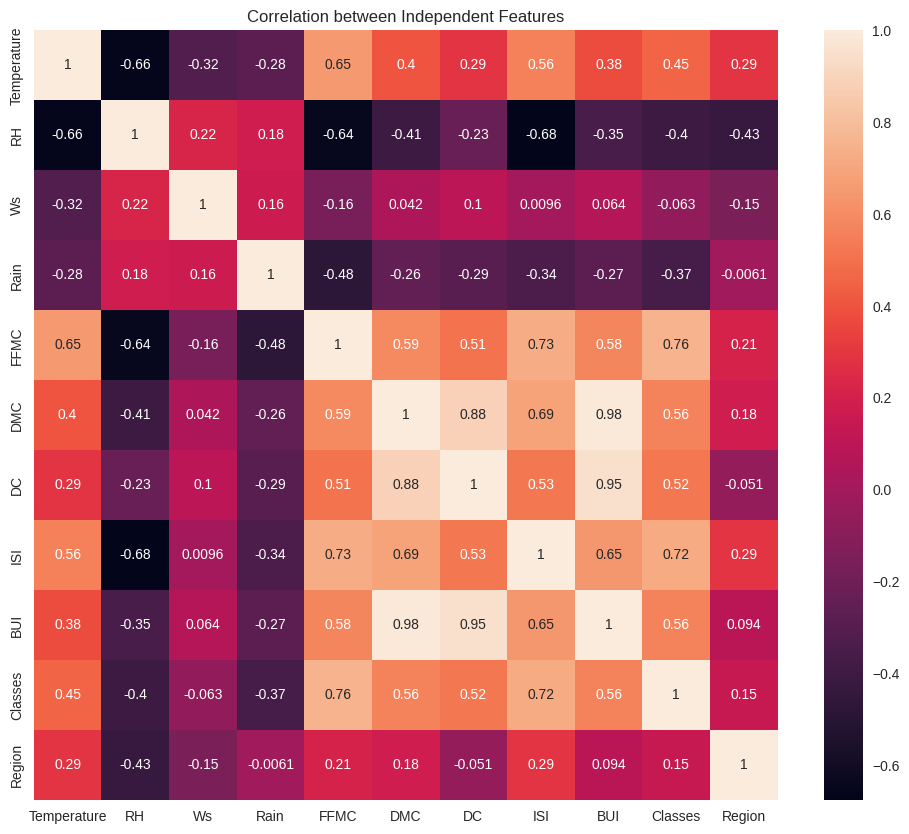

In [128]:
corr =  X_train.corr()
plt.figure(figsize=(12,10))
plt.title('Correlation between Independent Features')
sns.heatmap(corr,annot=True)
plt.show()

In [129]:
# Checking columns with High Correlation i.e 0.85

def correlation_check(dataset,threshold):
  corr_matrix = dataset.corr()
  corr=set()
  col_list = dataset.columns
  for i in range(len(col_list)):
    for j in range(i+1,len(col_list)):
      if(corr_matrix.iloc[i,j]>threshold):
        corr.add(col_list[j])
  return corr

In [130]:
corr_features = correlation_check(X_train,0.85)
corr_features

{'BUI', 'DC'}

In [131]:
# Dropping above columns in X_train and X_test

X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [132]:
print('Shapes\nX Train ->',X_train.shape)
print('X Test ->',X_test.shape)

Shapes
X Train -> (170, 9)
X Test -> (73, 9)


###**ii) Feature Scaling Or Standardization**

---



In [133]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###**iii) Linear Regression**

Mean Absolute Error: 0.8595885909676498
R2 Score: 0.9743401117847806




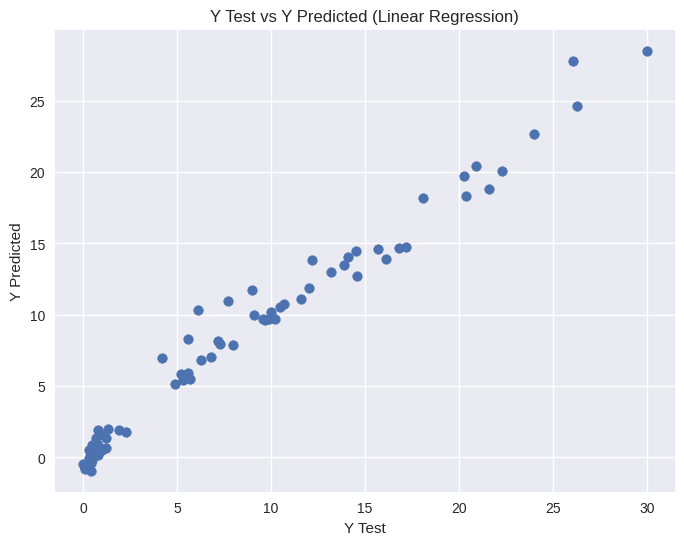

In [134]:
#Prediction

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred = lr.predict(X_test_scaled)

# Errors

mae = mean_absolute_error(y_test,y_pred)
score  = r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("R2 Score:",score)
print('\n')

# Graphs

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.title('Y Test vs Y Predicted (Linear Regression)')
plt.xlabel('Y Test')
plt.ylabel('Y Predicted')
plt.show()

###**iv) Lasso Regression**

Mean Absolute Error: 1.5429112859158132
R2 Score: 0.9336593182268962




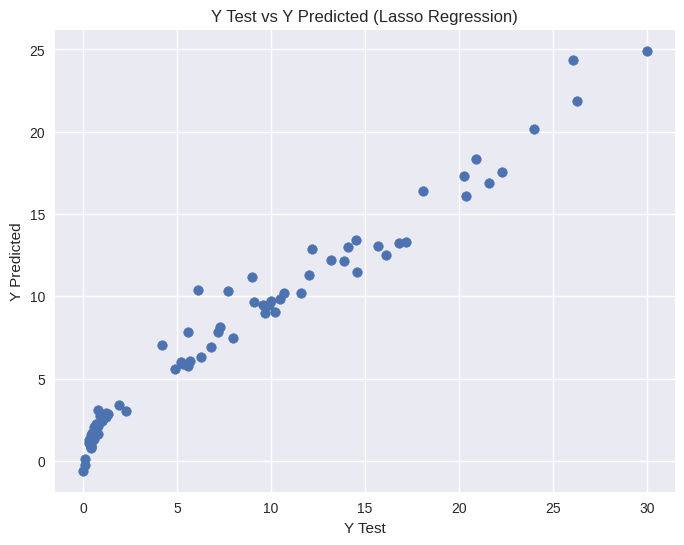

In [135]:
#Prediction

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score

ls = Lasso()
ls.fit(X_train_scaled,y_train)
y_pred = ls.predict(X_test_scaled)

# Errors

mae = mean_absolute_error(y_test,y_pred)
score  = r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("R2 Score:",score)
print('\n')

# Graphs

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.title('Y Test vs Y Predicted (Lasso Regression)')
plt.xlabel('Y Test')
plt.ylabel('Y Predicted')
plt.show()

###**v) Ridge Regression**

Mean Absolute Error: 0.8787543007872769
R2 Score: 0.9735429302286042




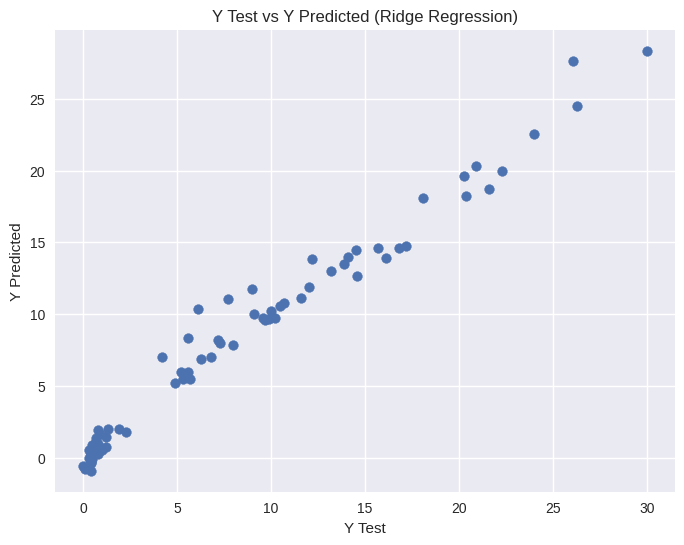

In [136]:
#Prediction

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score

rg = Ridge()
rg.fit(X_train_scaled,y_train)
y_pred = rg.predict(X_test_scaled)

# Errors

mae = mean_absolute_error(y_test,y_pred)
score  = r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("R2 Score:",score)
print('\n')

# Graphs

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.title('Y Test vs Y Predicted (Ridge Regression)')
plt.xlabel('Y Test')
plt.ylabel('Y Predicted')
plt.show()

###**vi) ElasticNet Regression**

Mean Absolute Error: 2.0575251478612118
R2 Score: 0.8729907116086603




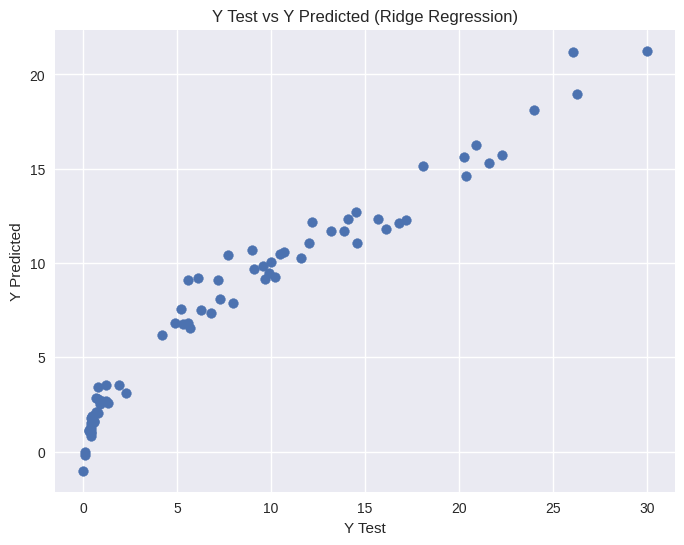

In [137]:
#Prediction

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score

en = ElasticNet()
en.fit(X_train_scaled,y_train)
y_pred = en.predict(X_test_scaled)

# Errors

mae = mean_absolute_error(y_test,y_pred)
score  = r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("R2 Score:",score)
print('\n')

# Graphs

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.title('Y Test vs Y Predicted (Ridge Regression)')
plt.xlabel('Y Test')
plt.ylabel('Y Predicted')
plt.show()